In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
from scipy import signal
from scipy.stats import linregress
from scipy.interpolate import UnivariateSpline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler

In [ ]:
df = pd.read_csv(r'C:\Users\zah48132\OneDrive - GSK\Documents\GitHub\PVRIG_StateSpace_Model\Current\Experiment_Data.csv')
df.head()

,Batch,Condition,Day,Sample Time,TCC,VCC,Lact,Osmo,Gluc,Ammonium,IGG,F30 Feed Amount (mL),Glucose Added (mL),Volume
0,AR22-001-002,CSFR: 0.00023 to 0.00037,0,1/19/2022 13:32,27.5054,27.4820,0.68,332.0,6.96,3.85,100.0,1.15,0.0,179.68
1,AR22-001-003,CSFR: 0.00037 to 0.0004 to 0.00023,0,1/19/2022 13:38,24.3893,24.3867,0.69,333.0,6.93,3.82,100.0,1.65,0.0,180.19
2,AR22-001-004,CSFR: 0.0003,0,1/19/2022 13:44,24.5271,24.5024,0.69,333.0,6.84,3.83,100.0,1.33,0.0,179.86
3,AR22-001-005,CSFR: 0.0001 to 0.0004 to 0.0001,0,1/19/2022 13:50,24.2632,24.2632,0.70,333.0,6.89,3.91,100.0,0.44,0.0,178.98
4,AR22-001-006,CSFR: 0.00023 to 0.0002 to 0.00037,0,1/19/2022 13:55,25.2902,25.2668,0.71,334.0,6.79,3.88,100.0,1.06,0.0,179.60


In [ ]:
df['savgol'] = df.groupby('group')['value'].transform(lambda x: savgol_filter(x, 5,2))

In [3]:
batch_dict = {}
poly_fit = True
x = np.linspace(0,12,13)
for i in df['Batch'].unique():
    df_batch = df[df['Batch']==i]
    df_batch = df_batch[['Day','TCC','VCC','Lact','Gluc','Osmo','Ammonium','IGG','F30 Feed Amount (mL)','Glucose Added (mL)','Volume']]
    df_batch.interpolate(method = 'linear',inplace=True)
    df_batch.interpolate(method = 'backfill', inplace=True,limit_direction='backward',limit=2)
    df_batch['Daily Feed Fed (mL)'] = np.diff(df_batch['F30 Feed Amount (mL)'],n=1,prepend=0)
    df_batch['Daily Glucose Fed (mL)'] = np.diff(df_batch['Glucose Added (mL)'],n=1,prepend=0)
    df_batch['CSFR'] = (df_batch['Daily Feed Fed (mL)']/(24*60))/(df_batch['VCC']*.18)
    spl_tcc = UnivariateSpline(x,df_batch['TCC'])
    spl_vcc = UnivariateSpline(x,df_batch['VCC'])
    spl_lact = UnivariateSpline(x,df_batch['Lact'])
    spl_osmo = UnivariateSpline(x,df_batch['Osmo'])
    spl_amm = UnivariateSpline(x,df_batch['Ammonium'])
    spl_igg = UnivariateSpline(x,df_batch['IGG'])
    #spl_gluc = UnivariateSpline(x,df_batch['Gluc'])
    #spl_feed = UnivariateSpline(x,df_batch['F30 Feed Amount (mL)'])
    if poly_fit == True:
        df_batch['TCC'] = spl_tcc(x)
        df_batch['VCC'] = spl_vcc(x)
        df_batch['Lact'] = spl_lact(x)
        #df_batch['Gluc'] = spl_gluc(x)
        df_batch['Osmo'] = spl_osmo(x)
        df_batch['Ammonium'] = spl_amm(x)
        df_batch['IGG'] = spl_igg(x)
        #df_batch['F30 Feed Amount (mL)'] = spl_feed(x)
    else:
        pass
    df_batch = df_batch.replace(np.nan,0)
    batch_dict[i] = df_batch
interpolated_df = pd.concat(batch_dict)

In [23]:
list1 = ["VCC", "TCC"]
df[set(df.columns) - set(list1)]

C:\Users\zah48132\AppData\Local\Temp\ipykernel_6244\3855193560.py:2: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  df[set(df.columns) - set(list1)]


,Day,Condition,Batch,Ammonium,Volume,Osmo,Gluc,Glucose Added (mL),IGG,F30 Feed Amount (mL),Lact,Sample Time
0,0,CSFR: 0.00023 to 0.00037,AR22-001-002,3.85,179.680,332.0,6.96,0.00,100.000,1.15,0.68,1/19/2022 13:32
1,0,CSFR: 0.00037 to 0.0004 to 0.00023,AR22-001-003,3.82,180.190,333.0,6.93,0.00,100.000,1.65,0.69,1/19/2022 13:38
2,0,CSFR: 0.0003,AR22-001-004,3.83,179.860,333.0,6.84,0.00,100.000,1.33,0.69,1/19/2022 13:44
3,0,CSFR: 0.0001 to 0.0004 to 0.0001,AR22-001-005,3.91,178.980,333.0,6.89,0.00,100.000,0.44,0.70,1/19/2022 13:50
4,0,CSFR: 0.00023 to 0.0002 to 0.00037,AR22-001-006,3.88,179.600,334.0,6.79,0.00,100.000,1.06,0.71,1/19/2022 13:55
...,...,...,...,...,...,...,...,...,...,...,...,...
268,12,CSFR: 0.00037 to 0.0002 to 0.00023,AR22-001-019,12.55,199.280,338.0,1.05,13.90,5526.315,31.33,0.25,1/31/2022 6:50
269,12,CSFR: 0.0005,AR22-001-016,30.86,231.610,710.0,4.47,7.80,3372.765,62.56,8.34,1/31/2022 6:26
270,12,CSFR: 0.0000 to 0.0007,AR21-048-009,17.56,213.330,416.0,2.91,16.79,5562.270,38.60,1.42,10/25/2021 9:50
271,12,CSFR: 0.0000 to 0.00035,AR21-048-003,8.56,187.920,288.0,0.45,13.29,5113.710,17.30,0.08,10/25/2021 9:44


In [24]:
df.groupby("Batch").size()

Batch
AR21-048-003    13
AR21-048-009    13
AR22-001-001    13
AR22-001-002    13
AR22-001-003    13
AR22-001-004    13
AR22-001-005    13
AR22-001-006    13
AR22-001-007    13
AR22-001-008    13
AR22-001-009    13
AR22-001-010    13
AR22-001-011    13
AR22-001-012    13
AR22-001-013    13
AR22-001-014    13
AR22-001-015    13
AR22-001-016    13
AR22-001-017    13
AR22-001-018    13
AR22-001-019    13
dtype: int64

In [8]:
grouped = df.groupby("Batch", group_keys=False)
grouped.apply(lambda group: group.interpolate(method = 'linear'))
grouped.apply(lambda group: group.interpolate(method = 'backfill', limit_direction='backward',limit=2))

,Batch,Condition,Day,Sample Time,TCC,VCC,Lact,Osmo,Gluc,Ammonium,IGG,F30 Feed Amount (mL),Glucose Added (mL),Volume
0,AR22-001-002,CSFR: 0.00023 to 0.00037,0,1/19/2022 13:32,27.5054,27.4820,0.68,332.0,6.96,3.85,100.000,1.15,0.00,179.680
1,AR22-001-003,CSFR: 0.00037 to 0.0004 to 0.00023,0,1/19/2022 13:38,24.3893,24.3867,0.69,333.0,6.93,3.82,100.000,1.65,0.00,180.190
2,AR22-001-004,CSFR: 0.0003,0,1/19/2022 13:44,24.5271,24.5024,0.69,333.0,6.84,3.83,100.000,1.33,0.00,179.860
3,AR22-001-005,CSFR: 0.0001 to 0.0004 to 0.0001,0,1/19/2022 13:50,24.2632,24.2632,0.70,333.0,6.89,3.91,100.000,0.44,0.00,178.980
4,AR22-001-006,CSFR: 0.00023 to 0.0002 to 0.00037,0,1/19/2022 13:55,25.2902,25.2668,0.71,334.0,6.79,3.88,100.000,1.06,0.00,179.600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,AR22-001-019,CSFR: 0.00037 to 0.0002 to 0.00023,12,1/31/2022 6:50,37.2307,31.8344,0.25,338.0,1.05,12.55,5526.315,31.33,13.90,199.280
269,AR22-001-016,CSFR: 0.0005,12,1/31/2022 6:26,28.6741,1.9370,8.34,710.0,4.47,30.86,3372.765,62.56,7.80,231.610
270,AR21-048-009,CSFR: 0.0000 to 0.0007,12,10/25/2021 9:50,30.4000,25.3270,1.42,416.0,2.91,17.56,5562.270,38.60,16.79,213.330
271,AR21-048-003,CSFR: 0.0000 to 0.00035,12,10/25/2021 9:44,29.3760,27.0760,0.08,288.0,0.45,8.56,5113.710,17.30,13.29,187.920


Batch
AR21-048-003    AxesSubplot(0.125,0.11;0.775x0.77)
AR21-048-009    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-001    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-002    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-003    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-004    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-005    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-006    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-007    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-008    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-009    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-010    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-011    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-012    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-013    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-014    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-015    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-016    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-017    AxesSubplot(0.125,0.11;0.775x0.77)
AR22-001-018    AxesSubpl

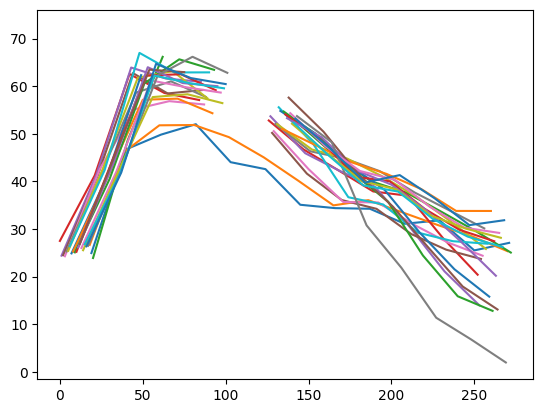

In [18]:
df.groupby('Batch')['VCC'].plot()